In [24]:
#1
import netCDF4
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
ds = xr.open_dataset("200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc", engine="netcdf4")

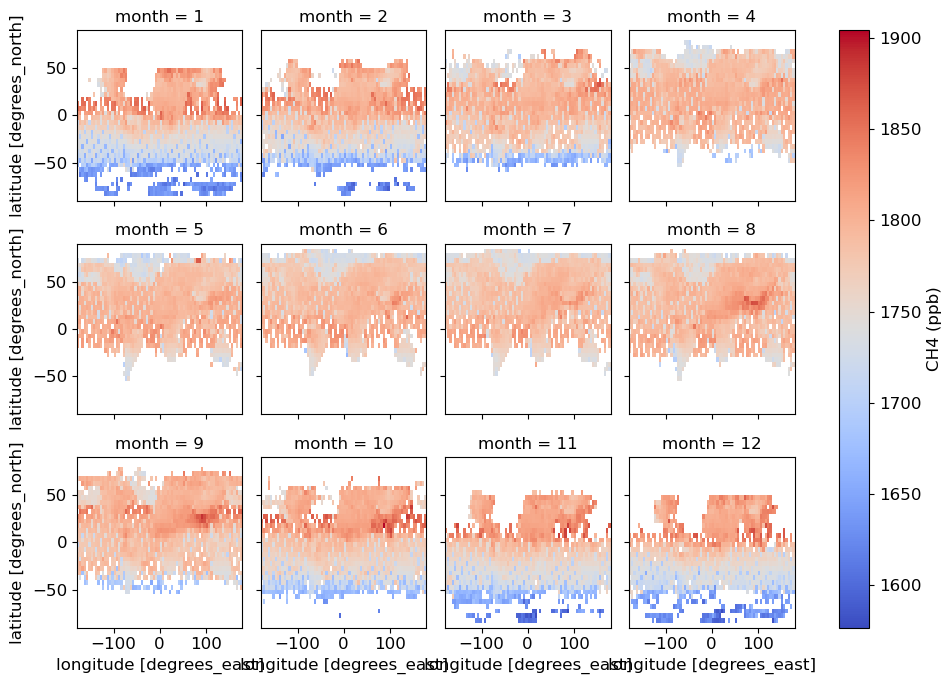

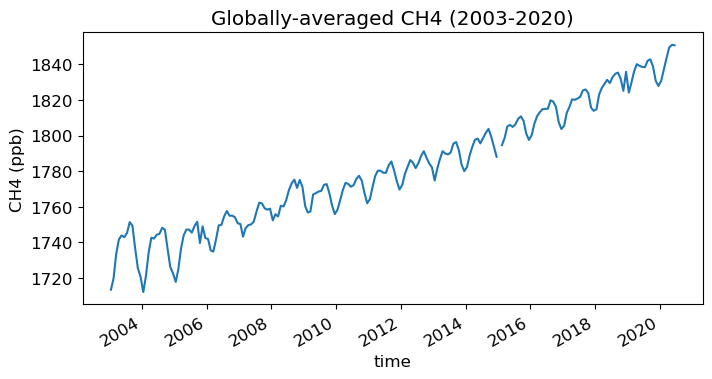

2003-2020 年全球平均 CH₄ 从 ~1770 ppb 升至 ~1860 ppb，且 2014 年后增速略有加快。


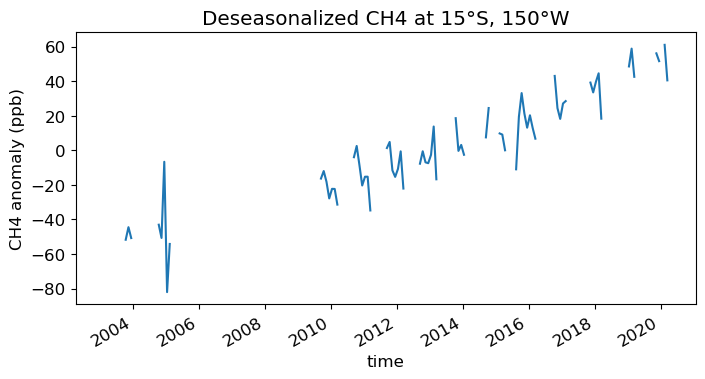

去季节后异常在±20ppb 范围内波动；2009-2011与2015-2017 出现正异常峰值，2020年初异常偏低，可能与全球疫情封锁有关。


In [38]:

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#1.1
ds = xr.open_dataset('200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc')
ds['xch4'] = ds['xch4'].where(ds['xch4'] != 1e20) * 1e9
clim = ds['xch4'].groupby('time.month').mean(dim='time')
clim.plot(col='month', col_wrap=4, figsize=(10, 7), cmap='coolwarm',
          cbar_kwargs={'label': 'CH4 (ppb)'})
plt.show()


# 1.2
weight = np.cos(np.deg2rad(ds.lat))
global_mean = ds['xch4'].weighted(weight).mean(dim=['lat', 'lon'])
global_mean.to_pandas().plot(figsize=(8, 4), title='Globally-averaged CH4 (2003-2020)')
plt.ylabel('CH4 (ppb)')
plt.show()
print('2003-2020 年全球平均 CH₄ 从 ~1770 ppb 升至 ~1860 ppb，且 2014 年后增速略有加快。')

#1.3
ts = ds['xch4'].sel(lat=-15, lon=-150, method='nearest')
monthly_mean = ts.groupby('time.month').mean()
anom = ts.groupby('time.month') - monthly_mean
anom.to_pandas().plot(figsize=(8, 4),
                      title='Deseasonalized CH4 at 15°S, 150°W')
plt.ylabel('CH4 anomaly (ppb)')
plt.show()
print('去季节后异常在±20ppb 范围内波动；2009-2011与2015-2017 出现正异常峰值，2020年初异常偏低，可能与全球疫情封锁有关。')

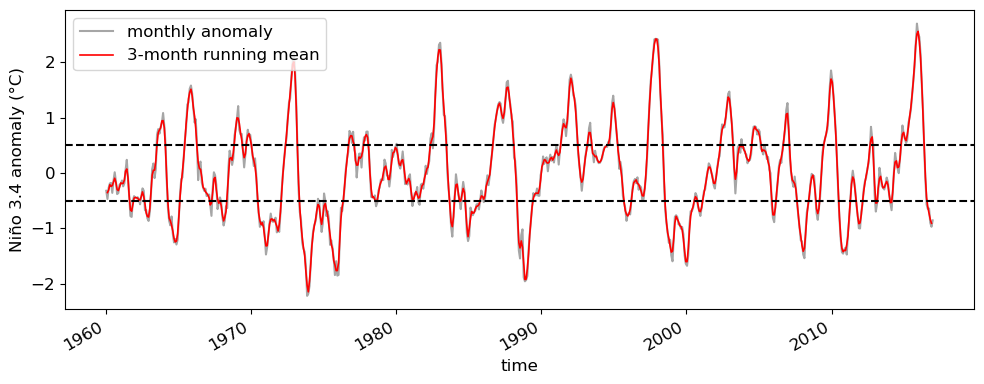

In [36]:
#2.
ds = xr.open_dataset('NOAA_NCDC_ERSST_v3b_SST.nc')

nino34 = ds['sst'].sel(lat=slice(-5, 5), lon=slice(190, 240))
nino34 = nino34.where((nino34 >= -3) & (nino34 <= 45))

weight = np.cos(np.deg2rad(nino34.lat))
nino34_mean = nino34.weighted(weight).mean(['lat', 'lon'])
#2.1
clim = nino34_mean.groupby('time.month').mean()
anom = nino34_mean.groupby('time.month') - clim
#2.2
anom_3m = anom.rolling(time=3, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))
anom.to_pandas().plot(ax=ax, label='monthly anomaly', color='grey', alpha=0.7)
anom_3m.to_pandas().plot(ax=ax, label='3-month running mean', color='r', linewidth=1.2)
ax.axhline(0.5, ls='--', c='k'); ax.axhline(-0.5, ls='--', c='k')
ax.set_ylabel('Niño 3.4 anomaly (°C)')
ax.legend(); plt.tight_layout(); plt.show()

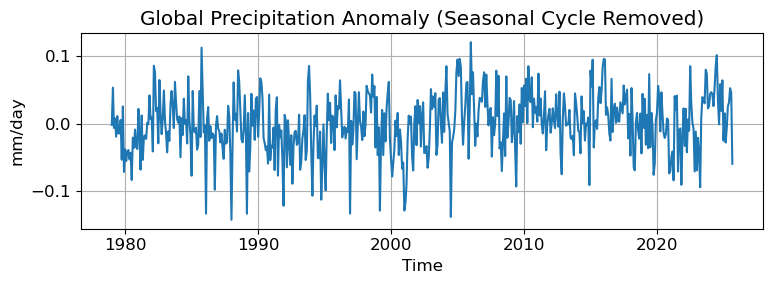

In [34]:
#3.
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.open_dataset("precip.mon.mean.nc")
precip = ds["precip"]   # (time, lat, lon)

# 3.1
climatology = precip.groupby("time.month").mean("time")
anomaly = precip.groupby("time.month") - climatology
global_mean = anomaly.mean(dim=["lat", "lon"])
plt.figure(figsize=(8,3))
global_mean.plot()
plt.title("Global Precipitation Anomaly (Seasonal Cycle Removed)")
plt.ylabel("mm/day")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()


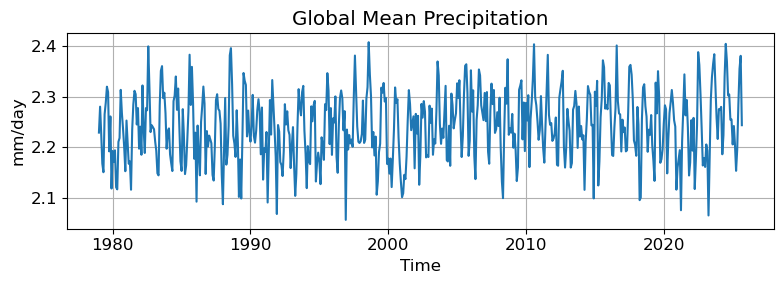

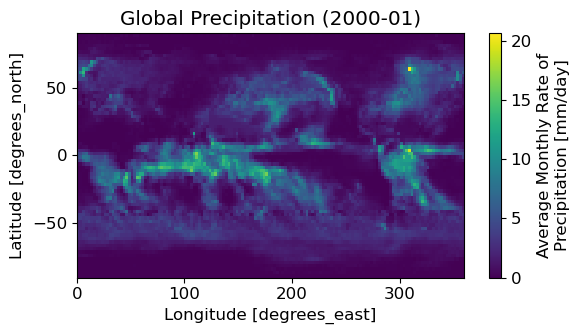

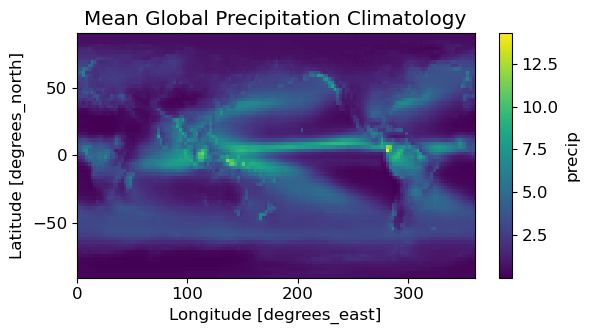

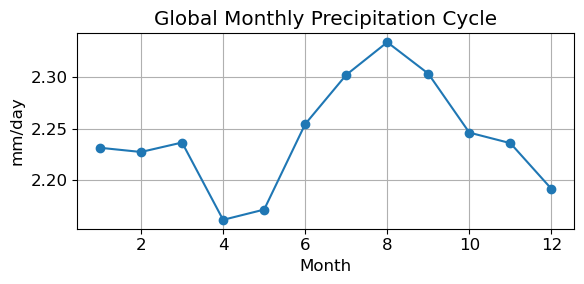

<function matplotlib.pyplot.show(close=None, block=None)>

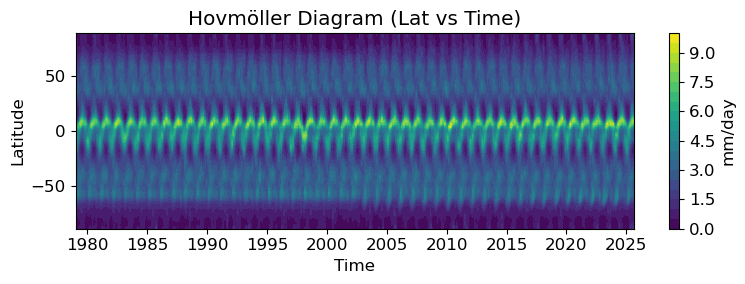

In [35]:
#3.2
#1.原始全球平均时间序列
plt.figure(figsize=(8,3))
precip.mean(dim=["lat", "lon"]).plot()
plt.title("Global Mean Precipitation")
plt.ylabel("mm/day")
plt.grid(True)
plt.tight_layout()
plt.show()
#2.2000 年 1 月全球降水空间分布
plt.figure(figsize=(6,3.5))
precip.sel(time="2000-01").plot()
plt.title("Global Precipitation (2000-01)")
plt.tight_layout()
plt.show()
#3.多年平均 climatology
plt.figure(figsize=(6,3.5))
precip.mean(dim="time").plot()
plt.title("Mean Global Precipitation Climatology")
plt.tight_layout()
plt.show()
#4.全球1–12月平均降水循环
monthly_cycle = precip.groupby("time.month").mean("time")
plt.figure(figsize=(6,3))
monthly_cycle.mean(dim=["lat","lon"]).plot(marker="o")
plt.title("Global Monthly Precipitation Cycle")
plt.xlabel("Month")
plt.ylabel("mm/day")
plt.grid(True)
plt.tight_layout()
plt.show()
#5.Hovmöller (lat-time)
hov = precip.mean(dim="lon") 
plt.figure(figsize=(8,3))
plt.contourf(hov["time"], hov["lat"], hov.T, levels=20)
plt.title("Hovmöller Diagram (Lat vs Time)")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.colorbar(label="mm/day")
plt.tight_layout()
plt.show